# Biomedical Image Analysis: **Project Setup and Data Understanding**

**Objective**

This notebook creates the groundwork for the project by performing the following tasks:

1. Setting up the Google Colab environment;
2. Downloading and verifying the synthetic nuclei dataset;
3. Exploring the dataset's documentation and metadata;
4. Verifying the data alignment and simple data quality checks;
5. Performing basic data inspection and analysis.

The following notebooks will build on this one in the following order:

**01 Setup & Data**

**02 Vision-Language Analysis**

**03 Classical Baseline**

**04 U-Net**

**05 Hybrid Pipeline & Robustness**


The dataset consists of synthetic fluorescence microscopy images with accompanying binary segmentation masks and metadata. The ground-truth masks are known for all of the images.

### **1. Environment Setup**

In [4]:
!pip install -q scikit-image pandas matplotlib

import os
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Working directory:", Path.cwd())

Working directory: /content


### **2. Project Paths and Reproducibility**

`PROJECT_DIR` directory will be used to store results from the notebooks (e.g trained model weights or results in csv format).

By default, it is set to the current directory inside the Colab runtime, which is convenient for quick tests that do not require authentication. However, if you restart the runtime, all results will be lost. To persist results between runs, mount Google Drive and save the results there. To do this, toggle `USE_DRIVE` to **"True"** and run the cell below that connects to Google Drive. The directory for saving files will be located in the Google Drive directory that will be connected.

In [5]:
from pathlib import Path
import sys

USE_DRIVE = True  # Set to False to skip Drive entirely and upload manually each session

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/biomedical_image_project")
else:
    PROJECT_DIR = Path("/content/biomedical_image_project")

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR = PROJECT_DIR / "src"
SRC_DIR.mkdir(parents=True, exist_ok=True)

if USE_DRIVE and (SRC_DIR / "biomedical_utils.py").exists():
    print("Found biomedical_utils.py on Drive, no upload needed.")
else:
    print("Please upload biomedical_utils.py")
    from google.colab import files
    uploaded = files.upload()
    import shutil
    shutil.move("biomedical_utils.py", str(SRC_DIR / "biomedical_utils.py"))

sys.path.insert(0, str(SRC_DIR))
from biomedical_utils import (
    ensure_dataset,
    load_metadata,
    preprocess_image,
    load_mask,
    check_split_integrity,
    extract_and_validate_json,
)

DATA_DIR = ensure_dataset()
metadata = load_metadata(DATA_DIR)

print("Dataset directory:", DATA_DIR)
print("Metadata shape:", metadata.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found biomedical_utils.py on Drive, no upload needed.
Dataset directory: /content/nuclei_dataset
Metadata shape: (112, 7)


### **3. Understand the dataset**

Firstly, to understand the dataset, we would observe the dataset description. This would help get an idea of what our images, masks, and labels represent before any pre-processing or transformations.

Furthermore, it is vital to comprehend how the data was divided.




In [6]:
readme_path = DATA_DIR / "README.md"
summary_path = DATA_DIR / "dataset_summary.json"

print("README.md")
print(readme_path.read_text())

print("\n dataset_summary.json")
print(json.dumps(json.loads(summary_path.read_text()), indent=2))

print("\n Metadata preview")
display(metadata.head())
print("Columns:", list(metadata.columns))

README.md
# Synthetic Stained-Nuclei Dataset (Biomedical Image Analysis assignment)

A small, self-contained **fluorescence-microscopy nuclei** dataset in the spirit of the
2018 Data Science Bowl set (images **and** ground-truth masks), created for the
Biomedical Image Analysis assignment. It is **fully synthetic**, so it can be
distributed to students without licensing constraints, and every image has an exact,
known ground truth — which makes it ideal for an assignment with an answer key.

## Contents
```
nuclei_dataset/
  train/  images/*.png  masks/*.png  labels/*.png   (80 pairs)
  val/    images/*.png  masks/*.png  labels/*.png   (20 pairs)
  test/   images/*.png  masks/*.png  labels/*.png   (12 pairs, treat as "unseen")
  test_corrupted/images/*.png                        (blurred / low-contrast variants)
  metadata.csv          ground-truth per image (n_objects, density, intensity, ...)
  dataset_summary.json
```
* **images** — 256x256 RGB, DAPI-like blue-stained nuclei on a da

,image_id,split,density,n_objects,mean_intensity,area_fraction,seed
0,train_000,train,sparse,10,0.747476,0.019333,20260715
1,train_001,train,normal,29,0.736130,0.086044,20260716
2,train_002,train,normal,17,0.703992,0.040680,20260717
3,train_003,train,normal,36,0.716404,0.101517,20260718
4,train_004,train,dense,85,0.763909,0.202789,20260719


Columns: ['image_id', 'split', 'density', 'n_objects', 'mean_intensity', 'area_fraction', 'seed']


*   Train: 80 images
*   Validation: 20 images
*   Test: 12 images

### **5. Inspect the metadata**

The metadata provides reliable reference data for every image, such as the expected number of objects and the density category.



While these details are helpful for **evaluation**, we would be careful to avoid using labels from the test set to adjust either the model or its decision thresholds.

In [7]:
print("Images per split:")
display(metadata["split"].value_counts().rename("count").to_frame())

print("Density regimes:")
display(
    metadata.groupby(["split", "density"])
    .size()
    .unstack(fill_value=0)
)

print("Object-count range by density:")
display(
    metadata.groupby("density")["n_objects"]
    .agg(["min", "median", "max", "count"])
    .sort_index()
)

Images per split:


,count
split,
train,80
val,20
test,12


Density regimes:


density,clustered,dense,normal,sparse
split,,,,
test,2,2,6,2
train,13,13,40,14
val,3,3,10,4


Object-count range by density:


,min,median,max,count
density,,,,
clustered,30,45.0,60,18
dense,46,68.5,85,18
normal,15,27.0,39,56
sparse,5,8.0,12,20


### **6. Verify image and mask integrity**

Before analyzing, we check if every image has a corresponding mask and the preprocessing step correctly produced masks of desired size and binary values.



This basic check would hep us ensures that there are no errors in the preparation step, since having inconsistent image-mask pairs would lead to incorrect results in all further steps.

In [8]:
integrity = check_split_integrity(DATA_DIR)
display(integrity)

assert integrity["filenames_match"].all(), "Image/mask filenames are not fully aligned."
assert all(tuple(shape) == (256, 256) for shape in integrity["image_shape"])
assert all(tuple(values) == (0, 1) for values in integrity["mask_values"])

print("Integrity checks passed.")

,split,n_images,n_masks,filenames_match,image_shape,mask_shape,mask_values
0,train,80,80,True,"(256, 256)","(256, 256)","(0, 1)"
1,val,20,20,True,"(256, 256)","(256, 256)","(0, 1)"
2,test,12,12,True,"(256, 256)","(256, 256)","(0, 1)"


Integrity checks passed.


In [9]:
integrity.to_csv(PROJECT_DIR / "integrity_check.csv", index=False)
print("Saved to:", PROJECT_DIR / "integrity_check.csv")

Saved to: /content/drive/MyDrive/biomedical_image_project/integrity_check.csv


### 7. **Visual inspection**

An initial understanding of the segmentation problem in later notebooks can be gained through the visual analysis of a few selected input-output samples.

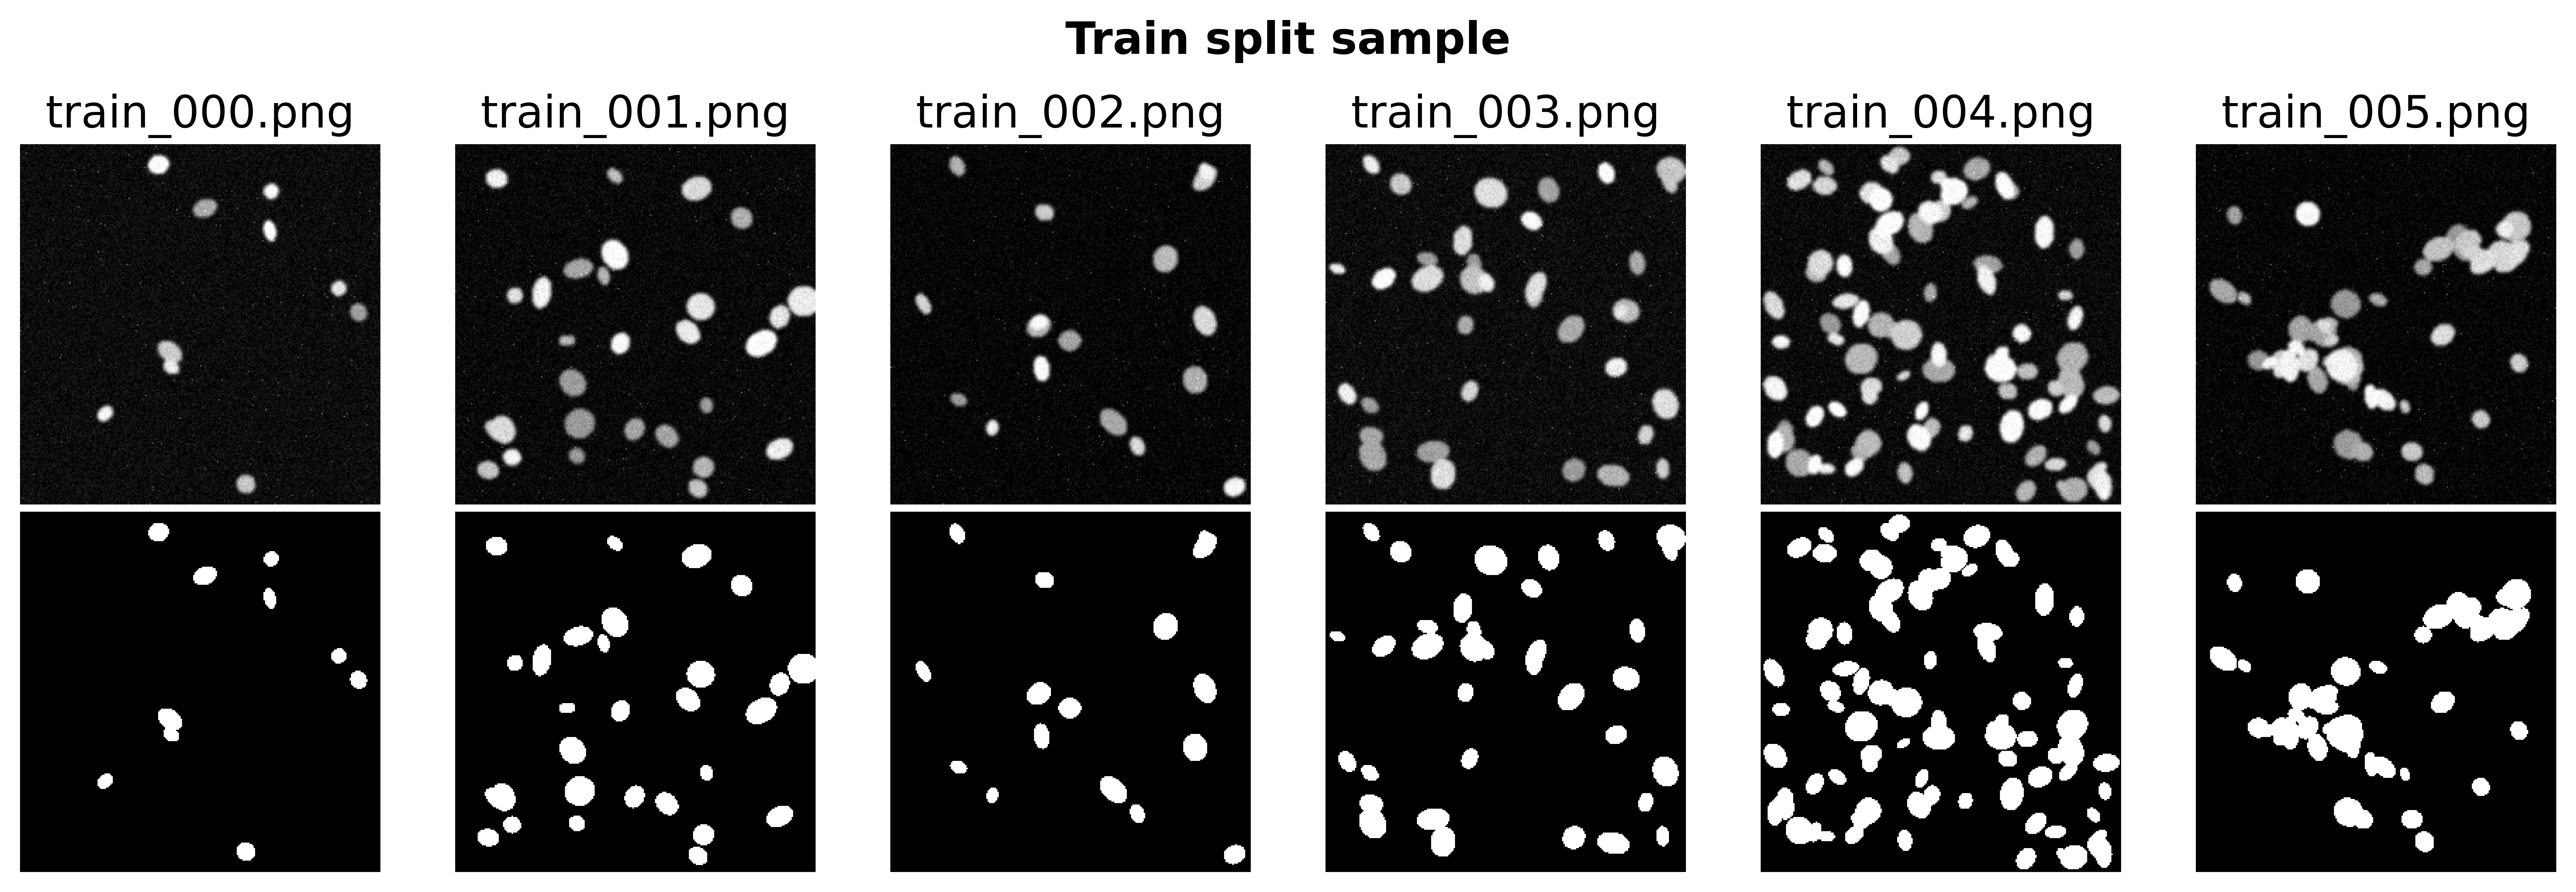

In [12]:
def show_sample_grid(split="train", n=6):
    image_dir = DATA_DIR / split / "images"
    mask_dir = DATA_DIR / split / "masks"
    filenames = sorted(os.listdir(image_dir))[:n]

    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 4.5), dpi=720)

    for i, filename in enumerate(filenames):
        image = preprocess_image(image_dir / filename)
        mask = load_mask(mask_dir / filename)

        axes[0, i].imshow(image, cmap="gray")
        axes[0, i].set_title(filename, fontsize=16)
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Grayscale image", fontsize=12)
    axes[1, 0].set_ylabel("Ground truth mask", fontsize=12)
    fig.suptitle(f"{split.title()} split sample", fontsize=16, fontweight='bold')
    plt.tight_layout()
    fig.savefig(PROJECT_DIR / "sample_grid.png", dpi=150, bbox_inches="tight")
    plt.show()

show_sample_grid("train", n=6)

The top row shows the grayscale preprocessed images, and the bottom row shows the corresponding binary ground-truth masks.

### **8. Pixel Intensity Analysis**

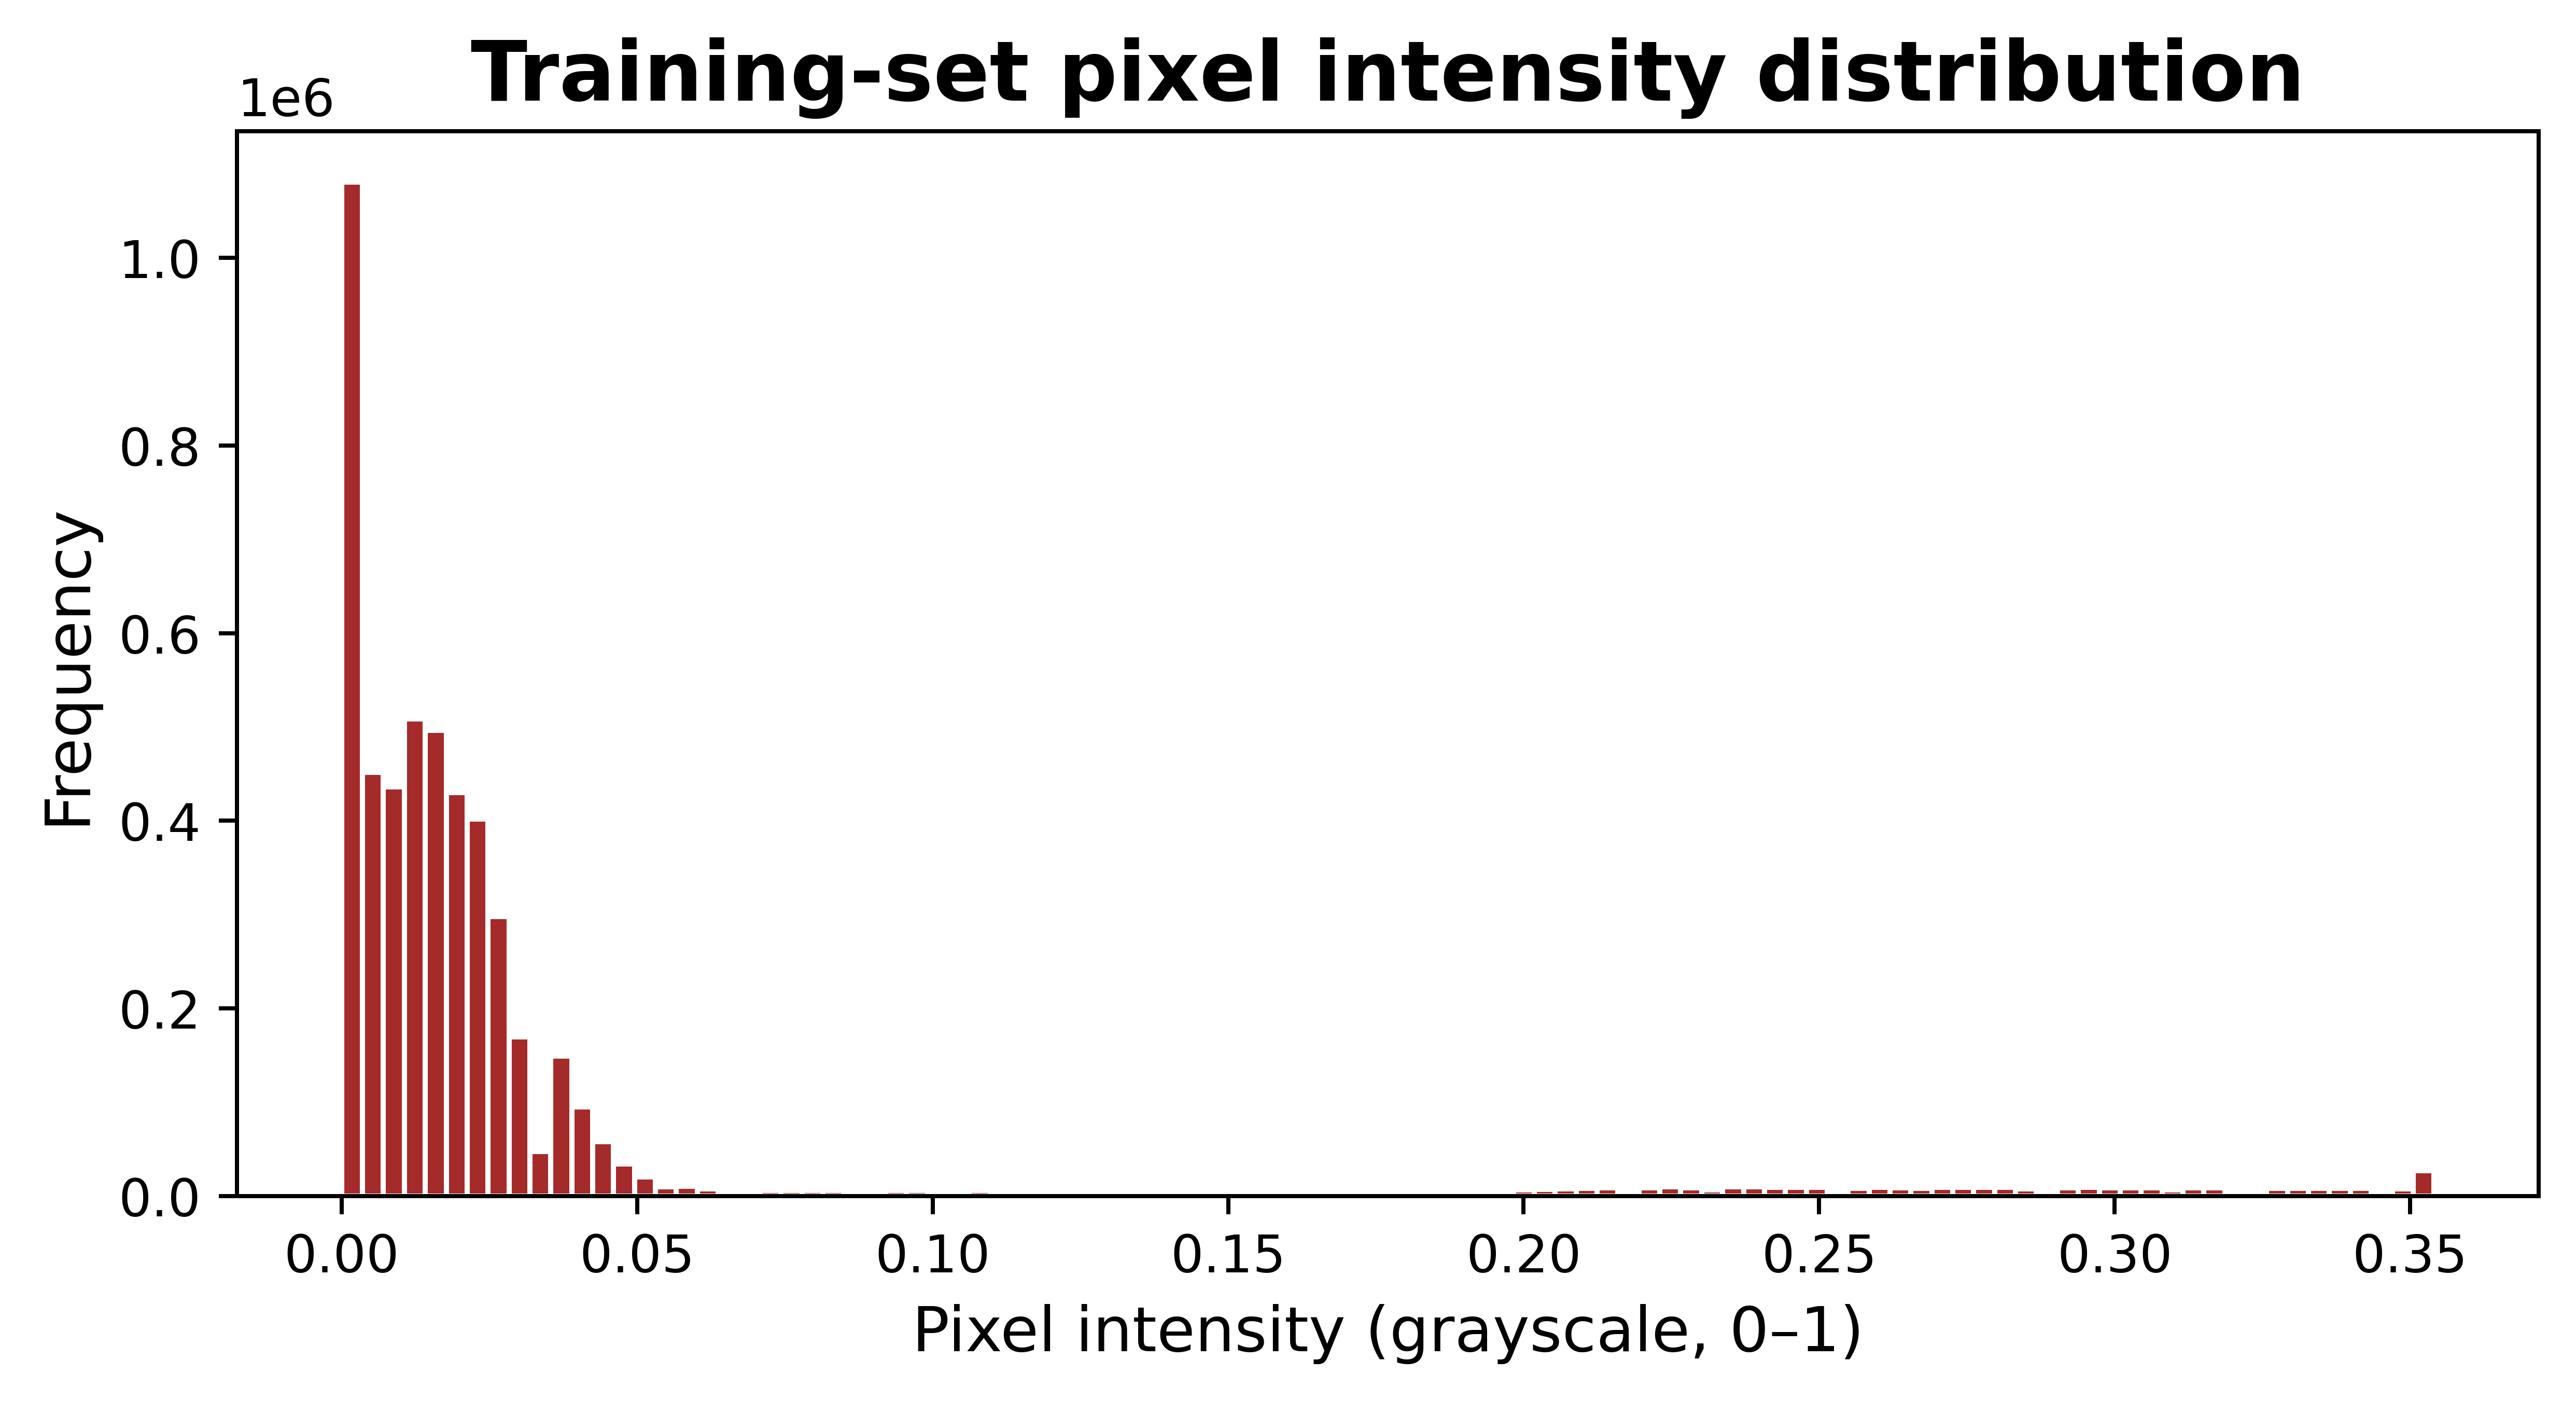

Mean intensity: 0.0367
Standard deviation: 0.0717
Near-zero background fraction: 88.85%


In [13]:
def collect_intensities(split="train", n_samples=None):
    image_dir = DATA_DIR / split / "images"
    filenames = sorted(os.listdir(image_dir))

    if n_samples is not None:
        filenames = filenames[:n_samples]

    pixels = [
        preprocess_image(image_dir / filename).ravel()
        for filename in filenames
    ]
    return np.concatenate(pixels)

train_pixels = collect_intensities("train")

plt.figure(figsize=(7, 4), dpi=720)
plt.hist(train_pixels, bins=100, color='brown', edgecolor="white")
plt.xlabel("Pixel intensity (grayscale, 0–1)", fontsize =12)
plt.ylabel("Frequency", fontsize=12)
plt.title(
    "Training-set pixel intensity distribution",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "intensity_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean intensity: {train_pixels.mean():.4f}")
print(f"Standard deviation: {train_pixels.std():.4f}")
print(f"Near-zero background fraction: {(train_pixels < 0.05).mean():.2%}")

As a part of the data preprocessing stage, RGB images were converted to grayscale, and their pixel intensities were normalized to fit the `[0, 1]` range.

The histogram above represents the distribution of pixel intensities for background and foreground. It will be necessary for the following analysis, as the standard Otsu thresholding algorithm relies on pixel intensity distribution to separate the foreground and background.

### **9. Preprocessing decisions**

The preprocessing is kept deliberately simple and minimalistic:

* RGB images are converted to grayscale using standard luminance weighting;
* resized to 256 × 256 pixels when needed;
* stored as float01 and;
* the masks are rescaled using nearest-neighbour interpolation to preserve sharp, unblurred class boundaries.
* No image files are excluded simply because they present challenges; including difficult cases helps assess model robustness more effectively.

In [14]:
preprocessing_log = {
    "grayscale": "0.2989R + 0.5870G + 0.1140B",
    "target_size": [256, 256],
    "image_range": [0, 1],
    "mask_interpolation": "nearest neighbour",
    "mask_encoding": "binary 0/1 after loading",
}
print(json.dumps(preprocessing_log, indent=2))

{
  "grayscale": "0.2989R + 0.5870G + 0.1140B",
  "target_size": [
    256,
    256
  ],
  "image_range": [
    0,
    1
  ],
  "mask_interpolation": "nearest neighbour",
  "mask_encoding": "binary 0/1 after loading"
}


In [15]:
with open(PROJECT_DIR / "preprocessing_log.json", "w") as f:
    json.dump(preprocessing_log, f, indent=2)
print("Saved to:", PROJECT_DIR / "preprocessing_log.json")

Saved to: /content/drive/MyDrive/biomedical_image_project/preprocessing_log.json


## What we have achieved

We have now compiled the dataset, established the preprocessing, and gained insight into the image structure.

Most importantly, we have separated the data preparation process, making the later notebooks simpler and reducing the risk of accidentally modifying the preprocessing.

### What we will do next

In the **`Task1_vision_language_prompting.ipynb`**, we will investigate how the vision-language model understands our images, how different prompts affect the results, and if it is robust enough to tolerate poor quality images.